In [1]:
from coffea_workflow import Step, Workflow, Fileset, Preprocessed, Analysis, Plotting, RunConfig, run, ExecutorConfig
from coffea_workflow import facilities
from ttbar_analysis import get_fileset, extract_sumw, run_analysis, plotting_1

step_fileset = Step(
    name="Fileset_ttbar",
    step_type=Fileset,
    builder=get_fileset,
    builder_params={"with_failure": False,
                    "n_files_max_per_sample": 5},  # 2 - 18 files - 19,497,435 events; 5 - 43 files - 47,996,231 events
    output="fileset_dict",
)

# NEW: explicit preprocessing into ~100k-event WorkItems (opens files on the Dask cluster).
# custom_builder=extract_sumw reads each file's sum of generator weights (Runs/genEventSumw)
# and stores it in the WorkItem usermeta -> events.metadata["sumw"] (demo of the hook).
step_preprocess = Step(
    name="Preprocess_ttbar",
    step_type=Preprocessed,
    step_size=100000,
    treename="Events",
    custom_builder=extract_sumw,
    input="fileset_dict",
    output="workitems",
)

step_analysis = Step(
    name="Analysis_ttbar",
    step_type=Analysis,
    builder=run_analysis,
    builder_params={"use_inference": False},       # ML inference needs xgboost + models/
    input="workitems",
    # input="fileset_dict",
    output="analysis_payload",
)

step_plot1 = Step(
    name="Plot_ttbar",
    step_type=Plotting,
    builder=plotting_1,
    input="analysis_payload",
)

workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_preprocess, depends_on=[step_fileset])
workflow.add(step_analysis, depends_on=[step_preprocess])
# workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plot1, depends_on=[step_analysis])


Step(name='Plot_ttbar', step_type=<class 'coffea_workflow.artifacts.Plotting'>, builder=<function plotting_1 at 0x7fd3a7c1c220>, builder_params=None, processor=None, processor_params=None, runner_params=None, step_size=None, treename=None, custom_builder=None, aggregate_builder=None, facility=None, executor_config=None, input='analysis_payload', output=None)

Workflow DAG:
  [0] Fileset_ttbar -> Fileset builder=<function get_fileset at 0x7fd79ef753a0>
  [1] Preprocess_ttbar -> Preprocessed step_size=100000
  [2] Analysis_ttbar -> Analysis builder=<function run_analysis at 0x7fd3a7bee8e0>
  [3] Plot_ttbar -> Plotting builder=<function plotting_1 at 0x7fd3a7c1c220>
Edges:
  Fileset_ttbar -> Preprocess_ttbar
  Preprocess_ttbar -> Analysis_ttbar
  Analysis_ttbar -> Plot_ttbar

Run config:
  Strategy:  by_dataset
  Executor:  DaskExecutor  workers=None
  Facility:  CoffeaCasaFactory

Executing step 'Fileset_ttbar' of type 'Fileset' with the user code <function get_fileset at 0x7fd79ef753a0> and user parameters {'with_failure': False, 'n_files_max_per_sample': 5}
Extracted from cache: .cache_preprocess_larger_sample/Fileset/5003a64290474097d6a7432c1cabc9221ba4997dd73be5142129926f6154d011
  -> materialized at .cache_preprocess_larger_sample/Fileset/5003a64290474097d6a7432c1cabc9221ba4997dd73be5142129926f6154d011

Executing step 'Preprocess_ttbar' 

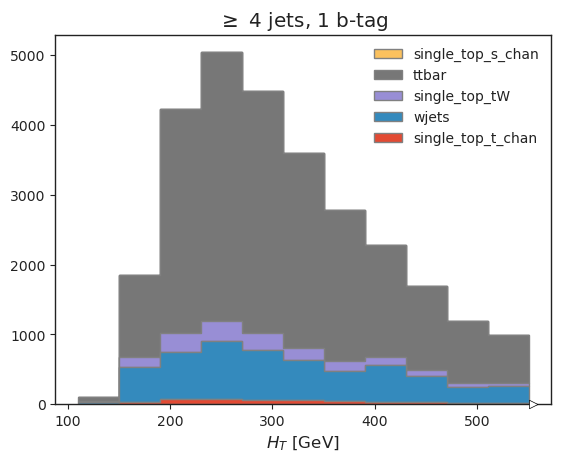

In [2]:
# Option A: make the Preprocess step's parallel file-opening work on the Dask workers.
# It ships coffea_workflow.preprocessing.extract_file_metadata to the workers BY REFERENCE,
# so the workers must be able to `import coffea_workflow` — install it from the same
# fork/branch as the driver via worker_packages. (No custom_builder is used here, so the
# Preprocess step needs nothing from ttbar_analysis; ttbar_analysis.py + utils are still
# uploaded because the Analysis step ships TtbarAnalysis by reference.)
facility = facilities.CoffeaCasaFactory(
    worker_packages=(
        "coffea>=2026.7.0",
        "git+https://github.com/hooloobooroodkoo/coffea-workflow.git@preprocessing",
    ),
    worker_files=("ttbar_analysis.py", "utils", "corrections.json"),
)
config = RunConfig(
    strategy="by_dataset",      # one chunk per dataset is processed independently and lost if something breaks inside this chunk processing (of its WorkItems)
    percentage=5, # each 5 percents of each dataset is processed independently
    cache_dir=".cache_preprocess_larger_sample",
    facility=facility,
    executor_config=ExecutorConfig(executor_type="DaskExecutor", parallel_chunks=True),
)
result = run(workflow, config)